<a href="https://colab.research.google.com/github/nisanthg1010/AI-ML-Rynixsoft/blob/main/Rynixsoft3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 Loading Dataset...
   intern_id    name      department  attendance_percentage  tasks_completed  \
0          1  Sanjay           Cloud                  86.28               19   
1          2    Neha           Cloud                  86.38               19   
2          3  Sanjay      Mobile App                  85.47                9   
3          4   Aditi      Mobile App                  95.19                8   
4          5   Arjun  Cyber Security                  85.99               18   

   tasks_pending  avg_task_score  mentor_feedback_score  communication_score  \
0              6            7.20                   7.71                 8.18   
1              1            8.29                   9.04                 8.30   
2              8            7.02                   8.32                 6.90   
3             10            9.08                   8.98                 9.04   
4              9            9.41                   8.52                 7.90   

   teamwork_score

/tmp/ipykernel_567/1051862000.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

📊 Accuracy Comparison
Random Forest: 1.0
Logistic Regression: 0.99

📄 Classification Report (Random Forest)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        72
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00         3

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



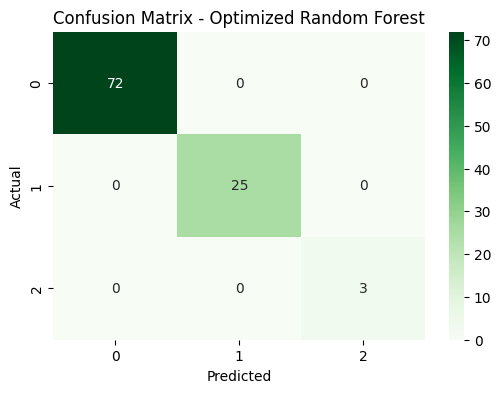

/tmp/ipykernel_567/1051862000.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


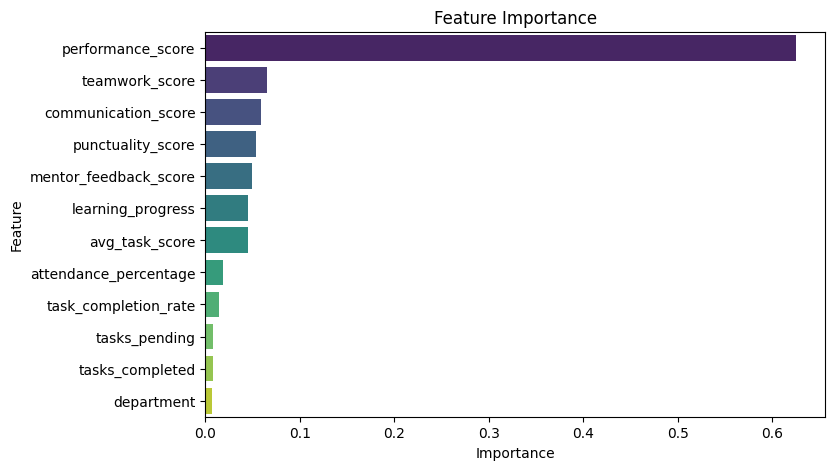


✅ Results saved as sprint3_model_results.csv

🎉 Sprint 3 Completed Successfully!


In [1]:
# ============================================
# INTERN PERFORMANCE PREDICTION - SPRINT 3
# Optimization & Evaluation
# ============================================

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# 1️⃣ Load Dataset
# ============================================

print("📂 Loading Dataset...")
df = pd.read_csv("/content/intern_performance_500_dataset.csv")

print(df.head())

# ============================================
# 2️⃣ Data Cleaning
# ============================================

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Encode categorical variables
le = LabelEncoder()
df['department'] = le.fit_transform(df['department'])
df['final_performance'] = le.fit_transform(df['final_performance'])

# ============================================
# 3️⃣ Feature Engineering
# ============================================

print("\n⚙️ Feature Engineering...")

# New features
df['task_completion_rate'] = df['tasks_completed'] / (df['tasks_completed'] + df['tasks_pending'])
df['performance_score'] = (
    df['avg_task_score'] +
    df['mentor_feedback_score'] +
    df['communication_score'] +
    df['teamwork_score'] +
    df['punctuality_score'] +
    df['learning_progress']
) / 6

# Handle division errors
df.replace([np.inf, -np.inf], 0, inplace=True)

print("New Features Added!")

# ============================================
# 4️⃣ Feature Selection
# ============================================

X = df.drop(['intern_id','name','final_performance'], axis=1)
y = df['final_performance']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================
# 5️⃣ Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ============================================
# 6️⃣ Model Optimization (Random Forest)
# ============================================

print("\n🌲 Optimizing Random Forest...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

# ============================================
# 7️⃣ Train Logistic Regression (Baseline)
# ============================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_pred_log = log_model.predict(X_test)

# ============================================
# 8️⃣ Evaluation Metrics
# ============================================

rf_acc = accuracy_score(y_test, y_pred_rf)
log_acc = accuracy_score(y_test, y_pred_log)

print("\n📊 Accuracy Comparison")
print("Random Forest:", rf_acc)
print("Logistic Regression:", log_acc)

# Classification Report
print("\n📄 Classification Report (Random Forest)\n")
print(classification_report(y_test, y_pred_rf))

# ============================================
# 9️⃣ Confusion Matrix Visualization
# ============================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================
# 🔟 Feature Importance
# ============================================

importances = best_rf.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')

plt.title("Feature Importance")
plt.show()

# ============================================
# 1️⃣1️⃣ Save Evaluation Report
# ============================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Optimized Random Forest"],
    "Accuracy": [log_acc, rf_acc]
})

results.to_csv("sprint3_model_results.csv", index=False)

print("\n✅ Results saved as sprint3_model_results.csv")

print("\n🎉 Sprint 3 Completed Successfully!")